FONTE: SINAN/DATASUS — datasus.saude.gov.br

Instalação

In [1]:
!pip install pymongo dnspython folium streamlit pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 84.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 93.5 MB/s eta 0:00:00


Importações

In [2]:
import json
import folium
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pymongo import MongoClient
from IPython.display import display

Conexão com o Atlas

In [ ]:
MONGO_URI = ""

client = MongoClient(MONGO_URI)
db     = client["dengue_db"]
col    = db["dengue_2015"]

print(f"✅ Conectado! {col.count_documents({})} documentos na coleção.")

✅ Conectado! 0 documentos na coleção.


In [5]:
with open("dengue_brasil_2015.json", "r", encoding="utf-8") as f:
    dados = json.load(f)

col.insert_many(dados)
print(f"✅ {col.count_documents({})} documentos inseridos!")

✅ 27 documentos inseridos!


Agrupamento por região

In [6]:
pipeline = [
    {
        "$group": {
            "_id": "$regiao",
            "total_casos": {"$sum": "$casos_confirmados"},
            "media_casos": {"$avg": "$casos_confirmados"},
            "num_estados": {"$sum": 1}
        }
    },
    {"$sort": {"total_casos": -1}}
]

resultado = list(col.aggregate(pipeline))

print(f"{'Região':<15} {'Total de Casos':>15} {'Média por Estado':>18} {'Nº Estados':>12}")
print("-" * 65)
for r in resultado:
    print(f"{r['_id']:<15} {r['total_casos']:>15,} {r['media_casos']:>18,.0f} {r['num_estados']:>12}")

Região           Total de Casos   Média por Estado   Nº Estados
-----------------------------------------------------------------
Sudeste               1,487,238            371,810            4
Nordeste                777,875             86,431            9
Centro-Oeste            327,522             81,880            4
Sul                     269,886             89,962            3
Norte                   144,054             20,579            7


Mapa 1 (total por região)

In [12]:
centros = {
    "Norte":        (-3.4653,  -62.2159),
    "Nordeste":     (-8.0476,  -34.8770),
    "Centro-Oeste": (-15.7801, -47.9292),
    "Sudeste":      (-19.9167, -43.9345),
    "Sul":          (-25.4284, -49.2733),
}

totais = {r["_id"]: r["total_casos"] for r in resultado}

mapa1 = folium.Map(location=[-14.2, -51.9], zoom_start=4, tiles="CartoDB positron")

for regiao, (lat, lon) in centros.items():
    total = totais.get(regiao, 0)
    folium.CircleMarker(
        location=[lat, lon],
        radius=15,
        color="#c0392b",
        fill=True,
        fill_color="#e74c3c",
        fill_opacity=0.75,
        tooltip=f"<b>{regiao}</b><br>Total: {total:,} casos",
        popup=folium.Popup(f"<b>Região {regiao}</b><br>Total: <b>{total:,}</b>", max_width=220)
    ).add_to(mapa1)

    folium.Marker(
        location=[lat, lon],
        icon=folium.DivIcon(
            html=f'<div style="font-size:10px;font-weight:bold;color:#c0392b;white-space:nowrap">{total:,}</div>',
            icon_size=(120, 20),
            icon_anchor=(0, -10)
        )
    ).add_to(mapa1)

display(mapa1)

Gráfico de média por região

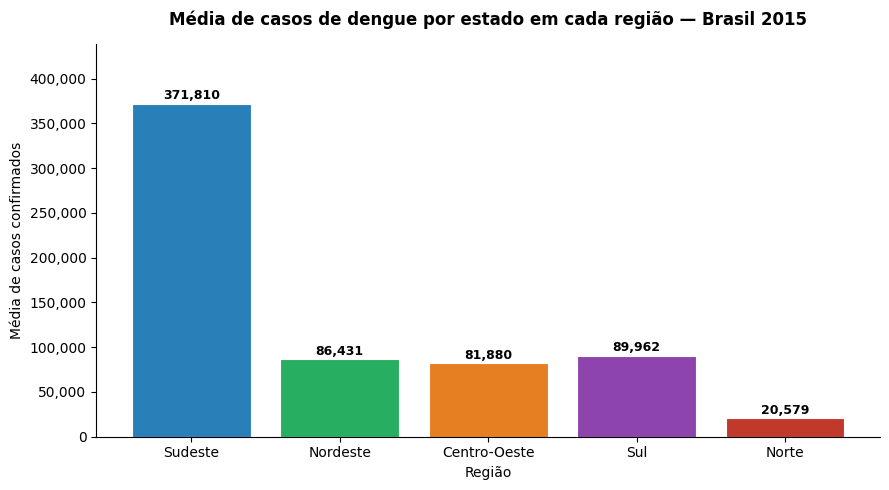

In [13]:
regioes = [r["_id"]        for r in resultado]
medias  = [r["media_casos"] for r in resultado]

cores = ["#2980b9", "#27ae60", "#e67e22", "#8e44ad", "#c0392b"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(regioes, medias, color=cores, edgecolor="white", linewidth=0.8)

for bar, val in zip(bars, medias):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2000,
            f"{val:,.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_title("Média de casos de dengue por estado em cada região — Brasil 2015",
             fontsize=12, fontweight="bold", pad=14)
ax.set_xlabel("Região", fontsize=10)
ax.set_ylabel("Média de casos confirmados", fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_ylim(0, max(medias) * 1.18)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("grafico_media_regiao.png", dpi=150)
plt.show()

Mapa 2 (cidades do Sudeste)

In [14]:
cidades_sudeste = [
    {"cidade": "São Paulo - SP",      "lat": -23.5505, "lon": -46.6333, "casos": 119_876},
    {"cidade": "Rio de Janeiro - RJ", "lat": -22.9068, "lon": -43.1729, "casos": 95_432},
    {"cidade": "Belo Horizonte - MG", "lat": -19.9191, "lon": -43.9386, "casos": 44_231},
    {"cidade": "Campinas - SP",       "lat": -22.9056, "lon": -47.0608, "casos": 31_745},
    {"cidade": "Guarulhos - SP",      "lat": -23.4543, "lon": -46.5333, "casos": 27_890},
    {"cidade": "Ribeirão Preto - SP", "lat": -21.1775, "lon": -47.8103, "casos": 17_654},
    {"cidade": "Sorocaba - SP",       "lat": -23.5015, "lon": -47.4526, "casos": 14_987},
    {"cidade": "Niterói - RJ",        "lat": -22.8833, "lon": -43.1036, "casos": 11_320},
]

mapa2 = folium.Map(location=[-21.5, -44.5], zoom_start=6, tiles="CartoDB positron")

for c in cidades_sudeste:
    raio = 6 + (c["casos"] / 15_000)
    folium.CircleMarker(
        location=[c["lat"], c["lon"]],
        radius=raio,
        color="#922b21",
        fill=True,
        fill_color="#e74c3c",
        fill_opacity=0.7,
        tooltip=f"<b>{c['cidade']}</b><br>{c['casos']:,} casos",
        popup=folium.Popup(f"<b>{c['cidade']}</b><br>Casos: <b>{c['casos']:,}</b>", max_width=220)
    ).add_to(mapa2)

display(mapa2)